<a href="https://colab.research.google.com/github/shailaja-ds/Sentiment-Analysis-NLP/blob/main/Sentiment_Analysis_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = {
    "text": [
        "I love this product",
        "The service was excellent",
        "Amazing experience",
        "I am very happy with the purchase",
        "This is a wonderful product",
        "I hate this product",
        "The service was terrible",
        "Very bad experience",
        "I am disappointed with the purchase",
        "This product is awful",
        "The product is okay",
        "The service was average",
        "It is neither good nor bad",
        "The experience was normal",
        "I have mixed feelings about this"
    ],
    "sentiment": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral"
    ]
}

df = pd.DataFrame(data)

print("Sentiment dataset created successfully!")
df

Sentiment dataset created successfully!


,text,sentiment
0,I love this product,Positive
1,The service was excellent,Positive
2,Amazing experience,Positive
3,I am very happy with the purchase,Positive
4,This is a wonderful product,Positive
5,I hate this product,Negative
6,The service was terrible,Negative
7,Very bad experience,Negative
8,I am disappointed with the purchase,Negative
9,This product is awful,Negative


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSentiment Counts:")
print(df["sentiment"].value_counts())

Dataset Shape:
(15, 2)

Missing Values:
text         0
sentiment    0
dtype: int64

Duplicate Rows:
0

Sentiment Counts:
sentiment
Positive    5
Negative    5
Neutral     5
Name: count, dtype: int64


In [1]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

print("Text preprocessing completed!")
df[["text", "clean_text", "sentiment"]]

NameError: name 'df' is not defined

In [2]:
Sentiment dataset created successfully!

SyntaxError: invalid syntax (2387582230.py, line 1)

In [3]:
import pandas as pd

data = {
    "text": [
        "I love this product",
        "The service was excellent",
        "Amazing experience",
        "I am very happy with the purchase",
        "This is a wonderful product",
        "I hate this product",
        "The service was terrible",
        "Very bad experience",
        "I am disappointed with the purchase",
        "This product is awful",
        "The product is okay",
        "The service was average",
        "It is neither good nor bad",
        "The experience was normal",
        "I have mixed feelings about this"
    ],
    "sentiment": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral"
    ]
}

df = pd.DataFrame(data)

print("Sentiment dataset created successfully!")
df

Sentiment dataset created successfully!


,text,sentiment
0,I love this product,Positive
1,The service was excellent,Positive
2,Amazing experience,Positive
3,I am very happy with the purchase,Positive
4,This is a wonderful product,Positive
5,I hate this product,Negative
6,The service was terrible,Negative
7,Very bad experience,Negative
8,I am disappointed with the purchase,Negative
9,This product is awful,Negative


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSentiment Counts:")
print(df["sentiment"].value_counts())

Dataset Shape:
(15, 2)

Missing Values:
text         0
sentiment    0
dtype: int64

Duplicate Rows:
0

Sentiment Counts:
sentiment
Positive    5
Negative    5
Neutral     5
Name: count, dtype: int64


In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

print("Text preprocessing completed!")
df[["text", "clean_text", "sentiment"]]

Text preprocessing completed!


,text,clean_text,sentiment
0,I love this product,i love this product,Positive
1,The service was excellent,the service was excellent,Positive
2,Amazing experience,amazing experience,Positive
3,I am very happy with the purchase,i am very happy with the purchase,Positive
4,This is a wonderful product,this is a wonderful product,Positive
5,I hate this product,i hate this product,Negative
6,The service was terrible,the service was terrible,Negative
7,Very bad experience,very bad experience,Negative
8,I am disappointed with the purchase,i am disappointed with the purchase,Negative
9,This product is awful,this product is awful,Negative


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

print("TF-IDF conversion completed!")
print("Feature Matrix Shape:", X.shape)

TF-IDF conversion completed!
Feature Matrix Shape: (15, 32)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12, 32)
Testing data: (3, 32)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
y_pred = model.predict(X_test)

print("Actual Sentiments:")
print(y_test.values)

print("\nPredicted Sentiments:")
print(y_pred)

Actual Sentiments:
['Negative' 'Positive' 'Neutral']

Predicted Sentiments:
['Positive' 'Negative' 'Negative']


In [10]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.0

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       1.0
     Neutral       0.00      0.00      0.00       1.0
    Positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [11]:
new_texts = [
    "I really love this amazing product",
    "This service is very bad",
    "The product is okay"
]

new_clean_texts = [clean_text(text) for text in new_texts]

new_vectors = vectorizer.transform(new_clean_texts)

predictions = model.predict(new_vectors)

for text, sentiment in zip(new_texts, predictions):
    print("Text:", text)
    print("Predicted Sentiment:", sentiment)
    print()

Text: I really love this amazing product
Predicted Sentiment: Positive

Text: This service is very bad
Predicted Sentiment: Negative

Text: The product is okay
Predicted Sentiment: Neutral



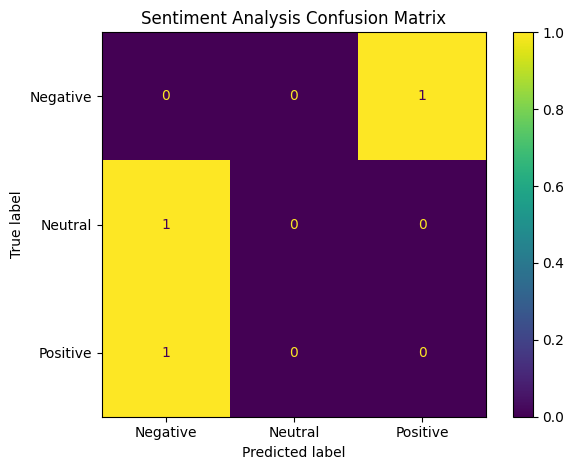

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()
plt.title("Sentiment Analysis Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
df.to_csv("dataset.csv", index=False)

print("dataset.csv created successfully!")

dataset.csv created successfully!


In [14]:
from google.colab import files

files.download("dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>